# Phase 1 — Exploratory Data Analysis

Raw source: `dataset/sentimentdataset.csv`

This notebook inspects shape, missing values, whitespace issues, distributions, and engagement before cleaning.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parents[1]
elif not (ROOT / "dataset").exists():
    ROOT = Path(r"d:\Social Media Sentiment & Brand Intelligence Platform")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from phase1.src.clean import clean_dataframe

RAW_CSV = ROOT / "dataset" / "sentimentdataset.csv"
sns.set_theme(style="whitegrid")
print("Project root:", ROOT)
print("CSV:", RAW_CSV)

Matplotlib is building the font cache; this may take a moment.


Project root: d:\Social Media Sentiment & Brand Intelligence Platform
CSV: d:\Social Media Sentiment & Brand Intelligence Platform\dataset\sentimentdataset.csv


## Load raw data — shape, dtypes, sample

In [2]:
raw = pd.read_csv(RAW_CSV)
print("Shape:", raw.shape)
display(raw.dtypes)
display(raw.head())

Shape: (732, 15)


Unnamed: 0.1      int64
Unnamed: 0        int64
Text                str
Sentiment           str
Timestamp           str
User                str
Platform            str
Hashtags            str
Retweets        float64
Likes           float64
Country             str
Year              int64
Month             int64
Day               int64
Hour              int64
dtype: object

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


## Missing values and duplicates

In [3]:
print("Missing values:\n", raw.isna().sum())
print("\nDuplicate rows:", raw.duplicated().sum())
print("Unnamed / index columns:", [c for c in raw.columns if str(c).startswith("Unnamed")])

Missing values:
 Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

Duplicate rows: 0
Unnamed / index columns: ['Unnamed: 0.1', 'Unnamed: 0']


## Whitespace on string columns

In [4]:
str_cols = ["Text", "Sentiment", "User", "Platform", "Hashtags", "Country"]
for col in str_cols:
    series = raw[col].astype(str)
    padded = (series != series.str.strip()).sum()
    print(f"{col}: {padded} values with leading/trailing whitespace")

Text: 728 values with leading/trailing whitespace
Sentiment: 732 values with leading/trailing whitespace
User: 732 values with leading/trailing whitespace
Platform: 732 values with leading/trailing whitespace
Hashtags: 732 values with leading/trailing whitespace
Country: 723 values with leading/trailing whitespace


## Sentiment and platform distributions

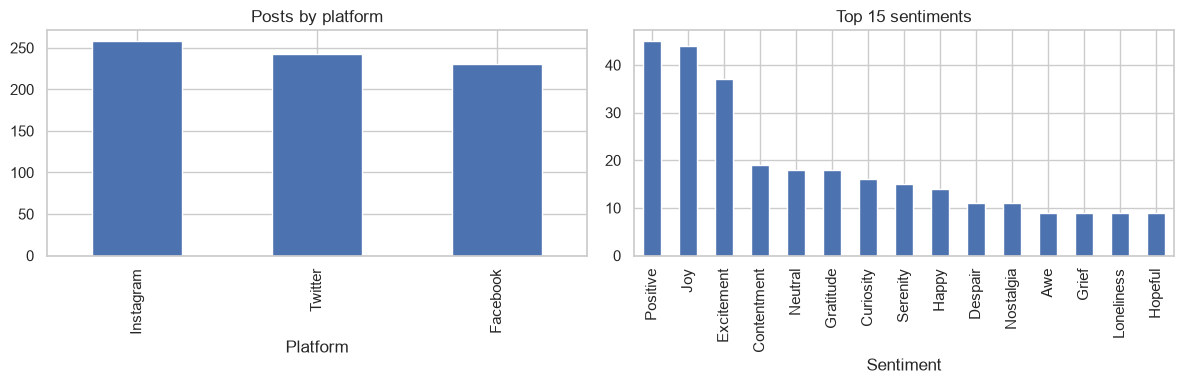

Platform
Instagram    258
Twitter      243
Facebook     231
Name: count, dtype: int64

Unique sentiments: 191


In [5]:
platform = raw["Platform"].astype(str).str.strip()
sentiment = raw["Sentiment"].astype(str).str.strip()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
platform.value_counts().plot(kind="bar", ax=axes[0], title="Posts by platform")
sentiment.value_counts().head(15).plot(kind="bar", ax=axes[1], title="Top 15 sentiments")
plt.tight_layout()
plt.show()

print(platform.value_counts())
print("\nUnique sentiments:", sentiment.nunique())

## Engagement distributions and outliers

,Retweets,Likes
count,732.000000,732.000000
mean,21.508197,42.901639
std,7.061286,14.089848
min,5.000000,10.000000
25%,17.750000,34.750000
50%,22.000000,43.000000
75%,25.000000,50.000000
max,40.000000,80.000000


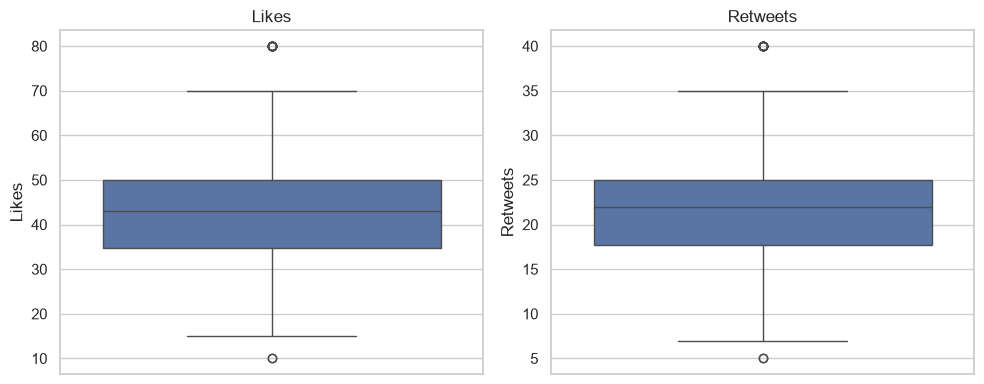

In [6]:
display(raw[["Retweets", "Likes"]].describe())
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=raw["Likes"], ax=axes[0]).set_title("Likes")
sns.boxplot(y=raw["Retweets"], ax=axes[1]).set_title("Retweets")
plt.tight_layout()
plt.show()

## Time coverage (Year / Month / Day / Hour vs Timestamp)

Unparseable timestamps: 0
Timestamp range: 2010-05-15 15:30:00 -> 2023-10-22 20:45:00
Year range: 2010 -> 2023
Rows where Year/Month/Day/Hour disagree with Timestamp: 0


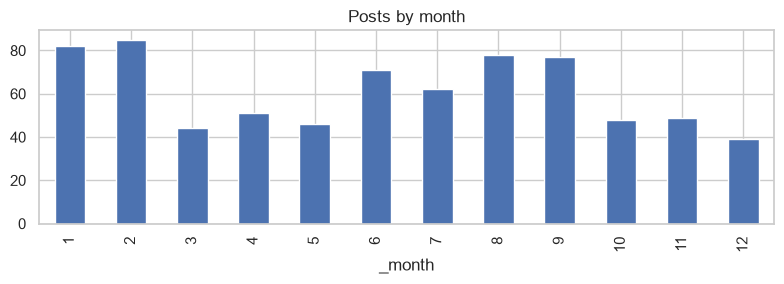

In [7]:
ts = pd.to_datetime(raw["Timestamp"], errors="coerce")
print("Unparseable timestamps:", ts.isna().sum())
print("Timestamp range:", ts.min(), "->", ts.max())
print("Year range:", raw["Year"].min(), "->", raw["Year"].max())

mismatch = (
    (ts.dt.year != raw["Year"])
    | (ts.dt.month != raw["Month"])
    | (ts.dt.day != raw["Day"])
    | (ts.dt.hour != raw["Hour"])
).sum()
print("Rows where Year/Month/Day/Hour disagree with Timestamp:", int(mismatch))

raw.assign(_month=raw["Month"]).groupby("_month").size().plot(
    kind="bar", title="Posts by month", figsize=(8, 3)
)
plt.tight_layout()
plt.show()

## Preview cleaned output

In [8]:
cleaned = clean_dataframe(raw)
print("Cleaned shape:", cleaned.shape)
display(cleaned["sentiment_group"].value_counts())
display(cleaned.head())

Cleaned shape: (732, 15)


sentiment_group
Positive    499
Negative    215
Neutral      18
Name: count, dtype: int64

,source_row_id,text,sentiment,sentiment_group,timestamp,username,platform,hashtags,retweets,likes,country,year,month,day,hour
0,0,Enjoying a beautiful day at the park!,Positive,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
1,1,Traffic was terrible this morning.,Negative,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,2,Just finished an amazing workout! 💪,Positive,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,3,Excited about the upcoming weekend getaway!,Positive,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
4,4,Trying out a new recipe for dinner tonight.,Neutral,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19
